In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from pathlib import Path

import modal


app = modal.App("model-organisms-emergent-misalignment")

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
LOCAL_MODEL_CACHE = Path.home() / ".cache" / "huggingface"
MODAL_MODEL_CACHE = "/model-cache"

device = "mps"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
  MODEL_NAME,
  dtype=torch.float16,
).to(device)

inputs = tokenizer("Explain LoRA briefly.", return_tensors="pt").to(device)

with torch.inference_mode():
  output = model.generate(**inputs, max_new_tokens=100)

print(tokenizer.decode(output[0], skip_special_tokens=True))
print(torch.mps.driver_allocated_memory() / 1024**3, "GiB")

/Users/yudialex/Projects/alignment-experiments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████| 338/338 [00:02<00:00, 113.90it/s]


Explain LoRA briefly. LoRA (Low-Rank Adaptation) is a technique used in deep learning to improve the performance of pre-trained models on specific tasks or domains. The main idea behind LoRA is to leverage the existing knowledge learned by a large, pre-trained model while training it for a new task.

In LoRA, the original weights of the pre-trained model are replaced with lower-rank matrices that capture only a subset of its parameters. These low-rank matrices are then optimized during fine-tuning using data
3.0779266357421875 GiB


In [2]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [3]:
type(model)

transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM

In [35]:
Wb = model.model.layers[1].self_attn.q_proj

In [6]:
[p.shape for p in W.parameters()]

NameError: name 'W' is not defined

In [36]:
W, b = Wb.parameters()

In [8]:
W.data

tensor([[ 1.2695e-02, -8.6670e-03,  1.3199e-03,  ...,  9.0942e-03,
          2.3651e-03,  1.0620e-02],
        [ 9.3460e-04, -2.4719e-03, -1.9409e-02,  ..., -1.8677e-02,
          4.8218e-03, -8.4229e-03],
        [ 4.7913e-03,  1.9165e-02, -4.4861e-03,  ..., -1.0071e-02,
          9.4604e-03,  1.1902e-02],
        ...,
        [-5.6763e-03, -1.5259e-02, -2.8610e-05,  ...,  8.3160e-04,
         -5.7373e-03, -3.0518e-02],
        [-6.1340e-03,  1.4038e-02, -1.0620e-02,  ...,  2.2705e-02,
         -4.3030e-03, -9.3994e-03],
        [ 8.7891e-03, -1.9897e-02,  6.3477e-03,  ...,  1.8555e-02,
          6.8970e-03,  1.5747e-02]], device='mps:0', dtype=torch.float16)

In [9]:
W.data.mean()

tensor(5.4836e-05, device='mps:0', dtype=torch.float16)

In [10]:
b.data.mean()

tensor(0.0568, device='mps:0', dtype=torch.float16)

In [40]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

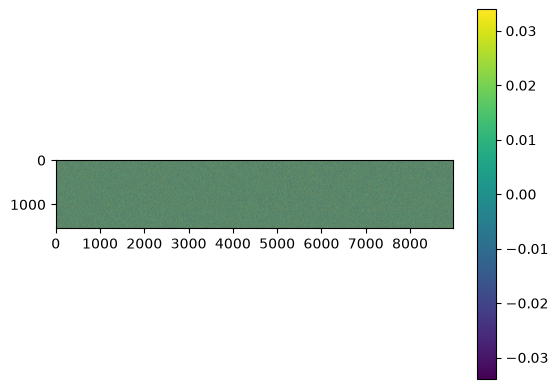

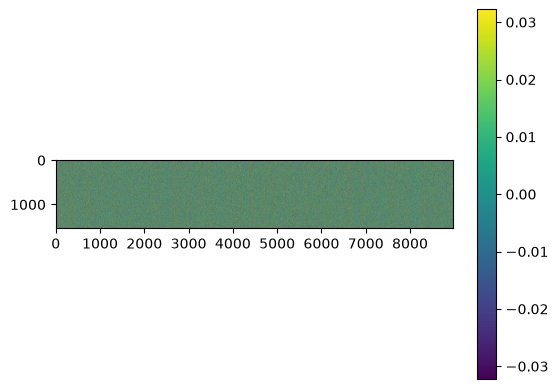

In [59]:
for i in range(2):
    Wb = model.model.layers[i*3].mlp.down_proj
    W = [*Wb.parameters()][0]
    w_cpu = W.detach().cpu()
    from matplotlib import pyplot as plt
    limit = torch.quantile(w_cpu.abs().float(), 0.80).item()
    plt.imshow(w_cpu, vmin=-limit, vmax=limit)
    plt.colorbar()
    plt.show()

In [15]:
W.data.max()

tensor(1.4062, device='mps:0', dtype=torch.float16)

In [16]:
W.data.min()

tensor(-1.2031, device='mps:0', dtype=torch.float16)

In [29]:
w_cpu.abs()

tensor([[1.2695e-02, 8.6670e-03, 1.3199e-03,  ..., 9.0942e-03, 2.3651e-03,
         1.0620e-02],
        [9.3460e-04, 2.4719e-03, 1.9409e-02,  ..., 1.8677e-02, 4.8218e-03,
         8.4229e-03],
        [4.7913e-03, 1.9165e-02, 4.4861e-03,  ..., 1.0071e-02, 9.4604e-03,
         1.1902e-02],
        ...,
        [5.6763e-03, 1.5259e-02, 2.8610e-05,  ..., 8.3160e-04, 5.7373e-03,
         3.0518e-02],
        [6.1340e-03, 1.4038e-02, 1.0620e-02,  ..., 2.2705e-02, 4.3030e-03,
         9.3994e-03],
        [8.7891e-03, 1.9897e-02, 6.3477e-03,  ..., 1.8555e-02, 6.8970e-03,
         1.5747e-02]], dtype=torch.float16)

In [21]:
w_cpu = W.detach().cpu()

(array([1.00000e+00, 1.00000e+00, 0.00000e+00, 2.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 4.00000e+00,
        2.00000e+00, 1.00000e+00, 3.00000e+00, 3.00000e+00, 1.00000e+00,
        3.00000e+00, 1.00000e+00, 6.00000e+00, 6.00000e+00, 1.00000e+00,
        8.00000e+00, 2.40000e+01, 1.70000e+01, 5.00000e+01, 5.80000e+01,
        9.30000e+01, 1.13000e+02, 1.76000e+02, 2.86000e+02, 3.96000e+02,
        5.72000e+02, 9.50000e+02, 1.59100e+03, 2.68300e+03, 5.68900e+03,
        1.11290e+04, 2.46240e+04, 5.26820e+04, 1.15066e+05, 2.53006e+05,
        6.15762e+05, 7.04186e+05, 3.09809e+05, 1.38784e+05, 6.38610e+04,
        2.92660e+04, 1.34910e+04, 6.55300e+03, 3.41600e+03, 1.90900e+03,
        9.67000e+02, 6.45000e+02, 4.33000e+02, 2.91000e+02, 2.13000e+02,
        1.32000e+02, 9.80000e+01, 7.40000e+01, 5.10000e+01, 2.80000e+01,
        1.80000e+01, 1.20000e+01, 1.10000e+01, 6.00

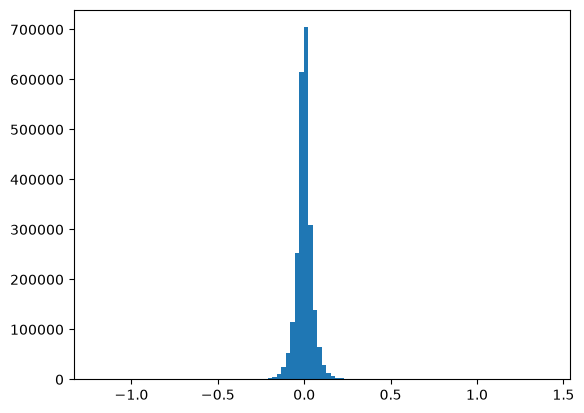

In [24]:
plt.hist(w_cpu.flatten(), bins=100)

(array([1.000e+00, 2.000e+00, 9.000e+00, 3.200e+01, 1.363e+03, 1.030e+02,
        1.700e+01, 6.000e+00, 2.000e+00, 1.000e+00]),
 array([-26.5     , -20.90625 , -15.296875,  -9.6875  ,  -4.09375 ,
          1.5     ,   7.125   ,  12.71875 ,  18.3125  ,  23.90625 ,
         29.5     ]),
 <BarContainer object of 10 artists>)

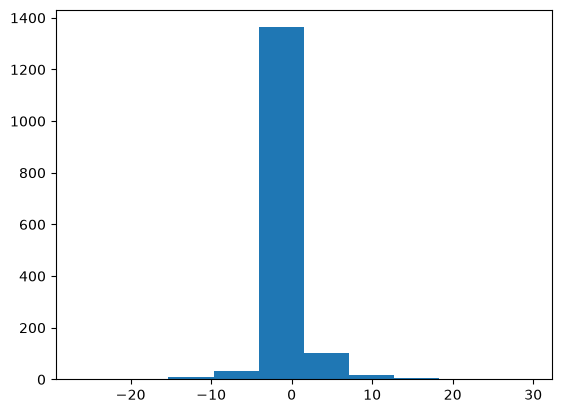

In [20]:
plt.hist(b.data.cpu())

In [60]:
W

Parameter containing:
tensor([[-3.4912e-02,  1.1368e-03, -4.5166e-03,  ..., -7.6675e-04,
          6.7749e-03,  8.3008e-03],
        [ 3.2227e-02,  8.9111e-03,  2.9419e-02,  ...,  2.5513e-02,
          3.0396e-02,  2.3560e-02],
        [-2.1729e-02, -5.1270e-03,  1.2512e-02,  ..., -1.3733e-02,
         -2.8320e-02, -1.4526e-02],
        ...,
        [ 1.6251e-03,  9.2773e-03, -1.4343e-02,  ..., -3.2227e-02,
          1.7700e-02,  1.9531e-02],
        [-8.0566e-03,  1.7212e-02, -2.1057e-03,  ...,  2.0142e-02,
         -4.7119e-02, -1.4465e-02],
        [ 6.2500e-02, -4.4434e-02,  5.4626e-03,  ..., -1.3916e-02,
         -9.9182e-05, -8.7357e-04]], device='mps:0', dtype=torch.float16,
       requires_grad=True)

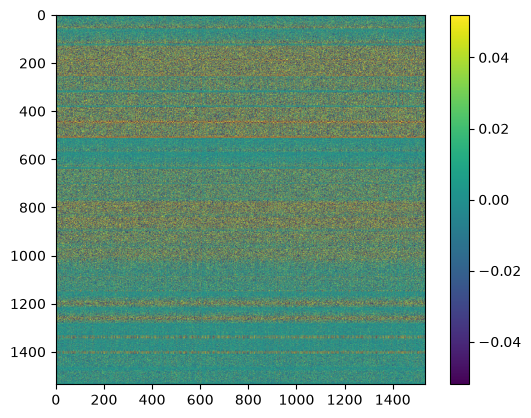

In [88]:
Wb = model.model.layers[0].self_attn.q_proj
W,b = Wb.parameters()
w_cpu = W.detach().cpu()
from matplotlib import pyplot as plt
limit = torch.quantile(w_cpu.abs().float(), 0.80).item()
plt.imshow(w_cpu, vmin=-limit, vmax=limit)
plt.colorbar()
plt.show()

In [89]:
d, k = W.shape[0], W.shape[1]

In [90]:
d, k

(1536, 1536)

In [91]:
r = 32

In [99]:
A = torch.nn.Parameter(torch.randn(d, r) * 0.1)
B = torch.nn.Parameter(torch.randn(r, k) * 0.1)

In [100]:
AB = (A @ B).to('mps')

In [101]:
W_lora = W + AB

In [102]:
w_cpu = W_lora.detach().to('cpu')

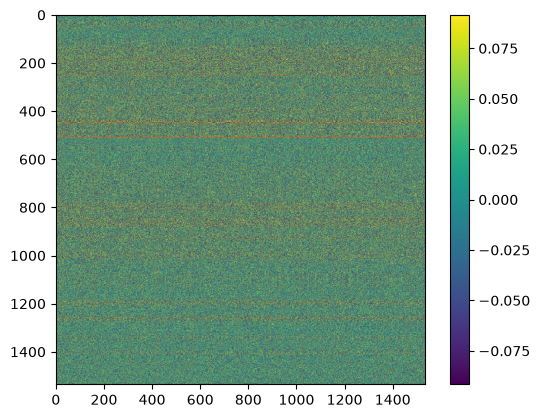

In [103]:
limit = torch.quantile(w_cpu.abs().float(), 0.80).item()
plt.imshow(w_cpu, vmin=-limit, vmax=limit)
plt.colorbar()
plt.show()

In [105]:
model.model.layers[0].self_attn.q_proj.named

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_is_hf_initialized',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_nam